# Линейная регрессия: теория и практика

Этот ноутбук — теоретический разбор линейной регрессии "с нуля": от
постановки задачи до диагностики обученной модели. Здесь используются
синтетические данные (специально сгенерированные), чтобы каждый эффект —
переобучение, влияние learning rate, работа регуляризации — можно было
показать изолированно и предсказуемо.

**Прикладной разбор на реальных данных** (House Prices) — в
[`notebooks/02_house_prices_eda.ipynb`](../notebooks/02_house_prices_eda.ipynb)
и [`scripts/train_house_prices.py`](../scripts/train_house_prices.py).

**Содержание:**
1. Постановка задачи
2. Функция потерь (MSE) и почему именно она
3. Аналитическое решение (нормальное уравнение) — реализация с нуля
4. Когда аналитика не работает
5. Градиентный спуск — реализация с нуля
6. Зачем нужна стандартизация признаков
7. Batch vs Stochastic vs Mini-batch GD
8. Полиномиальная регрессия: недо- и переобучение
9. Bias-variance tradeoff
10. Регуляризация: Ridge, Lasso, ElasticNet
11. Диагностика модели: остатки, гетероскедастичность, мультиколлинеарность
12. Метрики качества
13. Геометрическая интерпретация МНК
14. Резюме

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from utils.plotting import set_style, CATEGORICAL_PALETTE, plot_residuals

set_style()
rng = np.random.default_rng(42)

## 1. Постановка задачи

**Простая регрессия** (один признак): ищем прямую, наилучшим образом
описывающую зависимость $y$ от $x$:

$$\hat{y} = w_0 + w_1 x$$

**Множественная регрессия** ($k$ признаков) — то же самое, но в
пространстве большей размерности (гиперплоскость вместо прямой):

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_k x_k$$

Удобнее записать это в матричном виде для всей выборки сразу. Добавляем к
матрице признаков $X$ ($n \times k$) столбец единиц слева (для свободного
члена $w_0$), тогда:

$$\hat{y} = Xw, \qquad X \in \mathbb{R}^{n \times (k+1)},\quad w \in \mathbb{R}^{k+1}$$

Модель называется **линейной**, потому что предсказание — это линейная
комбинация признаков (не потому, что график обязан быть прямой линией —
ниже увидим, что полиномиальные признаки тоже укладываются в эту схему).

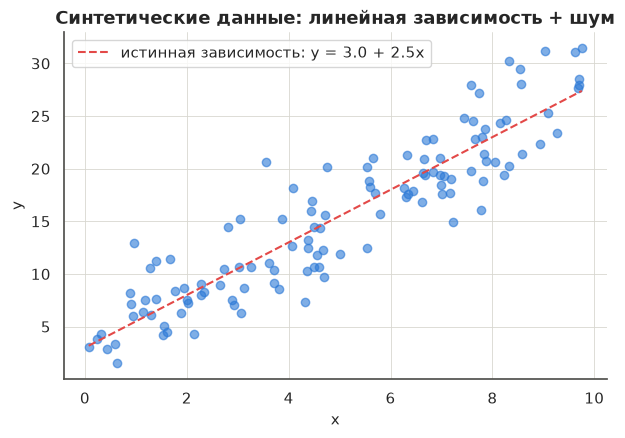

In [2]:
# Игрушечный датасет: линейная зависимость + шум
n_samples = 120
x = rng.uniform(0, 10, n_samples)
true_w0, true_w1 = 3.0, 2.5
y = true_w0 + true_w1 * x + rng.normal(0, 3.0, n_samples)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x, y, alpha=0.6, color=CATEGORICAL_PALETTE[0])
ax.plot(np.sort(x), true_w0 + true_w1 * np.sort(x), color=CATEGORICAL_PALETTE[3],
        linestyle="--", label=f"истинная зависимость: y = {true_w0} + {true_w1}x")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend()
ax.set_title("Синтетические данные: линейная зависимость + шум")
plt.show()

## 2. Функция потерь: почему MSE

Чтобы "наилучшим образом" стало математическим критерием, нужна функция
потерь — число, измеряющее, насколько плохо конкретная прямая описывает
данные. Стандартный выбор для линейной регрессии — **среднеквадратичная
ошибка (MSE)**:

$$MSE(w) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 = \frac{1}{n}\|y - Xw\|_2^2$$

Почему именно квадрат ошибки, а не, скажем, модуль (MAE)?

1. **Гладкость.** $MSE$ дифференцируема всюду, включая точку идеального
   прогноза — можно точно найти минимум через производную. У $MAE$ в нуле
   излом, производная не определена.
2. **Связь с максимальным правдоподобием.** Если предположить, что шум в
   данных распределён нормально (как мы и сгенерировали его выше), то
   минимизация $MSE$ эквивалентна максимизации правдоподобия — статистически
   самый обоснованный выбор именно для гауссовского шума.
3. **Штраф за крупные ошибки.** Квадрат растёт быстрее модуля — одна большая
   ошибка "стоит" непропорционально дороже нескольких маленьких. Это плюс,
   если крупные ошибки действительно нужно давить сильнее, но и минус —
   ровно поэтому MSE так чувствительна к выбросам (раздел 11).

$RMSE = \sqrt{MSE}$ возвращает ошибку в исходные единицы измерения $y$ —
удобнее для интерпретации, чем "квадратные" единицы MSE.

## 3. Аналитическое решение: нормальное уравнение

$MSE(w)$ — квадратичная (и строго выпуклая при невырожденной $X$) функция
от $w$, поэтому у неё есть единственный глобальный минимум, и его можно
найти напрямую, без итераций. Берём градиент и приравниваем к нулю:

$$\nabla_w MSE(w) = -\frac{2}{n}X^T(y - Xw) = 0 \;\Longrightarrow\; X^TXw = X^Ty$$

Если $X^TX$ обратима, получаем **нормальное уравнение**:

$$w^* = (X^TX)^{-1}X^Ty$$

Реализуем этот вывод буквально — по одной формуле, без обучения через
итерации:

In [3]:
class LinearRegressionOLS:
    """Линейная регрессия через нормальное уравнение w = (XtX)^-1 Xty."""

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        X_design = np.column_stack([np.ones(len(X)), X])  # столбец единиц под w0
        self.weights_ = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
        self.intercept_, self.coef_ = self.weights_[0], self.weights_[1:]
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.intercept_ + X @ self.coef_


ols = LinearRegressionOLS().fit(x.reshape(-1, 1), y)
sk_ols = LinearRegression().fit(x.reshape(-1, 1), y)

print(f"С нуля:   w0={ols.intercept_:.4f}, w1={ols.coef_[0]:.4f}")
print(f"sklearn:  w0={sk_ols.intercept_:.4f}, w1={sk_ols.coef_[0]:.4f}")
print(f"Истина:   w0={true_w0}, w1={true_w1}")

С нуля:   w0=2.9940, w1=2.4958
sklearn:  w0=2.9940, w1=2.4958
Истина:   w0=3.0, w1=2.5


Собственная реализация совпадает со `sklearn.LinearRegression` с точностью
до вычислительной погрешности — `sklearn` внутри тоже, по сути, решает
нормальное уравнение (точнее, использует более устойчивое SVD-разложение,
см. следующий раздел), просто быстрее и надёжнее на больших/плохо
обусловленных матрицах.

## 4. Когда аналитическое решение не работает

Формула $w^* = (X^TX)^{-1}X^Ty$ требует, чтобы $X^TX$ была обратима.
Это ломается, когда:

- **Признаков больше, чем наблюдений** ($k \geq n$) — система недоопределена.
- **Есть точная линейная зависимость между признаками** (идеальная
  мультиколлинеарность, например один признак — это удвоенный другой) —
  $X$ теряет полный ранг, $\det(X^TX) = 0$.

Продемонстрируем: добавим признак-дубликат `x2 = 2*x + 1` и посмотрим, что
происходит с обращением матрицы на практике. Важная деталь: из-за ошибок
округления с плавающей точкой `numpy` почти никогда не увидит *ровно* ноль
в определителе и не бросит исключение — вместо явного краха мы получим
**молчаливо неустойчивое** решение с огромными по модулю коэффициентами.
Именно это на практике опаснее честной ошибки: код не упадёт, а просто
выдаст мусор.

In [4]:
X_dup = np.column_stack([x, x * 2 + 1])  # второй столбец - точная линейная функция первого

cond_number = np.linalg.cond(np.column_stack([np.ones(len(x)), X_dup]))
print(f"Число обусловленности X: {cond_number:.2e}  (для сравнения, у исходного x было ~10)")

model_dup = LinearRegressionOLS().fit(X_dup, y)
print(f"Коэффициенты при [x, 2x+1]: {model_dup.coef_}")
print("Модель 'нашла' решение, но веса неустойчивы и не поддаются интерпретации:",
      "с исходным x1=2.5 они никак не связаны по отдельности, только их комбинация.")

Число обусловленности X: 2.45e+16  (для сравнения, у исходного x было ~10)
Коэффициенты при [x, 2x+1]: [ 6.12731005 -0.89062965]
Модель 'нашла' решение, но веса неустойчивы и не поддаются интерпретации: с исходным x1=2.5 они никак не связаны по отдельности, только их комбинация.


Число обусловленности взлетает до ~1e16 — это уровень точности `float64`,
то есть матрица численно неотличима от вырожденной. Полученные коэффициенты
(6.13 и -0.89) не имеют ничего общего с истинным наклоном `w1=2.5` по
отдельности — модель нашла лишь одно из бесконечного множества решений,
которые в сумме дают одинаковое предсказание $\hat y$ (проверьте:
$6.13 + 2\cdot(-0.89) \approx 4.3$, что уже не похоже на 2.5 — коэффициенты
перестали быть интерпретируемыми поодиночке) и которые непредсказуемо
меняются при малейшем изменении данных или округления.

На практике идеальная вырожденность встречается редко, а вот **близкая** к
ней ситуация (сильно, но не идеально коррелированные признаки) — постоянно.
Матрица технически обратима, но число обусловленности огромно, и малейший
шум в данных даёт колоссальный разброс оценок $w$ — коэффициенты становятся
нестабильными и плохо интерпретируемыми (это и есть мультиколлинеарность,
подробно — в разделе 11 и в `notebooks/02_house_prices_eda.ipynb`).

Практические решения:

- **Псевдообратная матрица** (Мура-Пенроуза, через SVD) — даёт решение с
  минимальной нормой весов даже для вырожденной $X^TX$; `sklearn` использует
  именно её, а не наивное обращение матрицы.
- **L2-регуляризация (Ridge)** — прибавляет $\lambda I$ к $X^TX$ перед
  обращением, что *всегда* делает матрицу обратимой (раздел 10).
- **Удаление/объединение коррелированных признаков** — самый прямой способ.

## 5. Градиентный спуск

Нормальное уравнение требует обращения матрицы $k \times k$ — при большом
числе признаков ($k$ в десятках/сотнях тысяч) это становится слишком дорого
по памяти и времени. **Градиентный спуск** — итеративная альтернатива:
двигаемся маленькими шагами в направлении, противоположном градиенту
(градиент указывает направление *роста* функции, поэтому спускаемся против
него):

$$w^{(t+1)} = w^{(t)} - \eta \cdot \nabla_w MSE(w^{(t)}), \qquad
\nabla_w MSE(w) = \frac{2}{n}X^T(Xw - y)$$

$\eta$ (learning rate) — размер шага. Реализуем с нуля и посмотрим на
траекторию спуска:

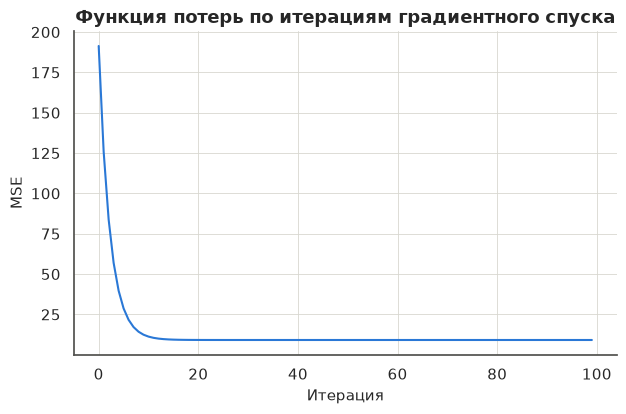

Финальный MSE: 9.1392


In [5]:
def gradient_descent(X, y, lr=0.01, n_iter=200):
    X_design = np.column_stack([np.ones(len(X)), X])
    w = np.zeros(X_design.shape[1])
    history = []
    for _ in range(n_iter):
        y_pred = X_design @ w
        grad = (2 / len(X)) * X_design.T @ (y_pred - y)
        w = w - lr * grad
        history.append(mean_squared_error(y, X_design @ w))
    return w, history

x_std = (x - x.mean()) / x.std()  # см. раздел 6, зачем это нужно
w_gd, loss_history = gradient_descent(x_std.reshape(-1, 1), y, lr=0.1, n_iter=100)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(loss_history, color=CATEGORICAL_PALETTE[0])
ax.set_xlabel("Итерация"); ax.set_ylabel("MSE")
ax.set_title("Функция потерь по итерациям градиентного спуска")
plt.show()
print(f"Финальный MSE: {loss_history[-1]:.4f}")

Кривая монотонно убывает и выходит на плато — спуск сошёлся. Посмотрим, как
на это влияет `learning rate`:

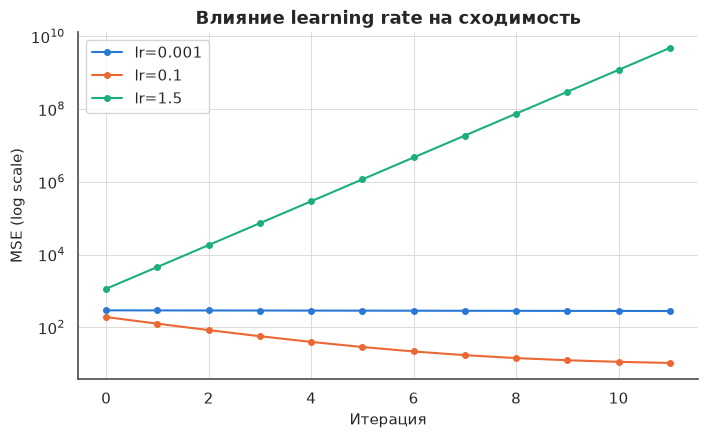

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for lr, color in zip([0.001, 0.1, 1.5], CATEGORICAL_PALETTE[:3]):
    _, history = gradient_descent(x_std.reshape(-1, 1), y, lr=lr, n_iter=12)
    ax.plot(history, "-o", ms=4, color=color, label=f"lr={lr}")
ax.set_yscale("log")
ax.set_xlabel("Итерация"); ax.set_ylabel("MSE (log scale)")
ax.set_title("Влияние learning rate на сходимость")
ax.legend()
plt.show()

- **Слишком маленький `lr`** (0.001) — шаги ничтожны, спуск за 12 итераций
  едва сдвинулся с места: сходимость есть, но неоправданно медленная.
- **Разумный `lr`** (0.1) — уверенно и быстро сходится за десяток шагов.
- **Слишком большой `lr`** (1.5) — алгоритм перепрыгивает через минимум на
  каждом шаге сильнее, чем приближается к нему; MSE не падает, а растёт
  от итерации к итерации — на графике это видно как взлёт по
  экспоненте (расходимость). Часто это первая и самая частая причина, по
  которой градиентный спуск "не работает" на практике.

Практический вывод: `lr` подбирается экспериментально (перебором/адаптивными
методами вроде Adam в нейросетях), и почти всегда полезно посмотреть именно
на такой график — "MSE от итерации" — как на первую диагностику.

## 6. Зачем нужна стандартизация признаков перед градиентным спуском

Если признаки имеют сильно разный масштаб (например, `LotArea` в
квадратных футах — сотни-тысячи, а `OverallQual` — от 1 до 10), поверхность
функции потерь становится сильно вытянутым "оврагом": вдоль одной оси она
крутая, вдоль другой — пологая. Градиентный спуск в таком овраге
зигзагообразно "бьётся о стенки" вместо того, чтобы идти прямо к минимуму.
Покажем это на двух признаках с разным масштабом:

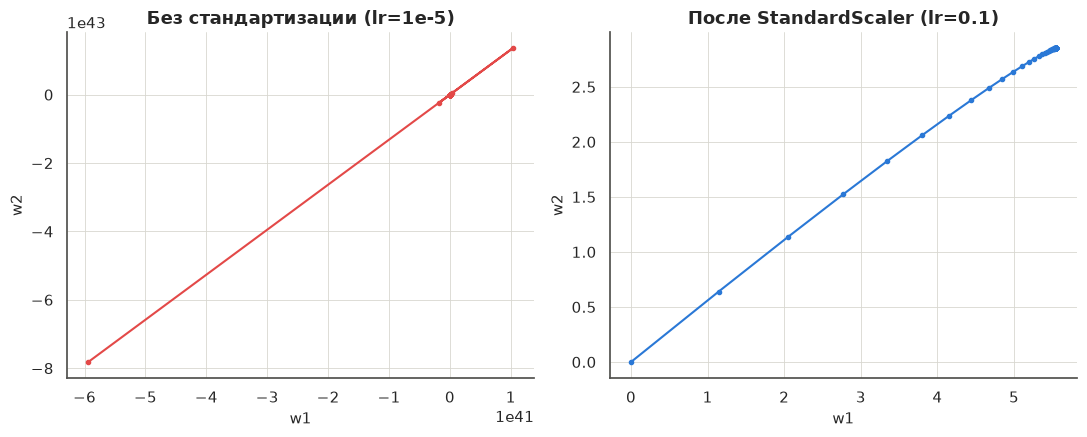

In [7]:
x1 = rng.uniform(0, 10, 150)
x2 = rng.uniform(0, 1000, 150)  # масштаб в 100 раз больше x1
y_multi = 2 * x1 + 0.01 * x2 + rng.normal(0, 1, 150)

def gd_track_weights(X, y, lr, n_iter=60):
    X_design = np.column_stack([np.ones(len(X)), X])
    w = np.zeros(X_design.shape[1])
    path = [w[1:].copy()]
    for _ in range(n_iter):
        grad = (2 / len(X)) * X_design.T @ (X_design @ w - y)
        w = w - lr * grad
        path.append(w[1:].copy())
    return np.array(path)

path_raw = gd_track_weights(np.column_stack([x1, x2]), y_multi, lr=1e-5)

X_scaled = StandardScaler().fit_transform(np.column_stack([x1, x2]))
path_scaled = gd_track_weights(X_scaled, y_multi, lr=0.1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(path_raw[:, 0], path_raw[:, 1], "-o", ms=3, color=CATEGORICAL_PALETTE[3])
axes[0].set_title("Без стандартизации (lr=1e-5)")
axes[1].plot(path_scaled[:, 0], path_scaled[:, 1], "-o", ms=3, color=CATEGORICAL_PALETTE[0])
axes[1].set_title("После StandardScaler (lr=0.1)")
for ax in axes:
    ax.set_xlabel("w1"); ax.set_ylabel("w2")
fig.tight_layout()
plt.show()

Без стандартизации пришлось искусственно занизить `lr` до 1e-5, чтобы спуск
вообще не разошёлся по "быстрой" координате — но тогда по "медленной"
координате он почти не двигается за то же число шагов. После
`StandardScaler` (каждый признак центрируется и делится на своё стандартное
отклонение — оба масштаба становятся сопоставимы) можно использовать
нормальный `lr` и путь к минимуму получается почти прямым. **Правило**:
перед градиентным спуском (и вообще перед регуляризацией — раздел 10)
признаки почти всегда стоит стандартизировать. На аналитическое решение
(нормальное уравнение) масштаб признаков не влияет так критично.

## 7. Batch, Stochastic и Mini-batch градиентный спуск

То, что мы реализовали выше — **batch GD**: градиент считается по *всей*
обучающей выборке на каждом шаге. Два практичных варианта:

- **SGD (Stochastic GD)** — градиент считается по **одному** случайному
  объекту за шаг. Каждый шаг намного дешевле, но зашумлён.
- **Mini-batch GD** — компромисс: градиент по небольшой случайной подвыборке
  (обычно 32-256 объектов). Это стандарт на практике (и в глубоком обучении
  в частности).

Сравним со встроенным `SGDRegressor`:

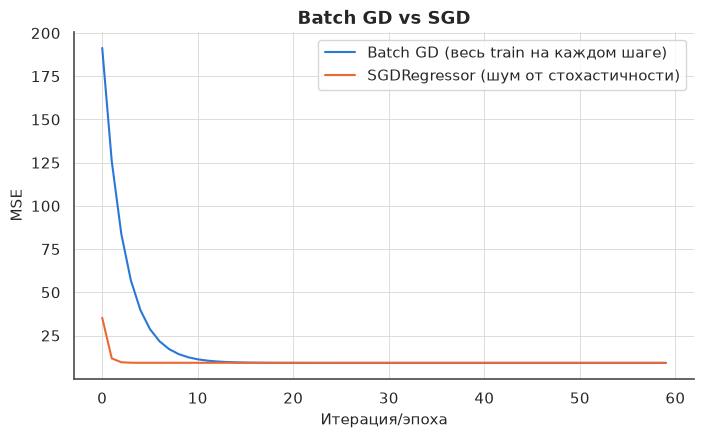

In [8]:
X_scaled_1d = StandardScaler().fit_transform(x.reshape(-1, 1))

sgd = SGDRegressor(max_iter=1, learning_rate="constant", eta0=0.01,
                    random_state=42, warm_start=True)
sgd_losses = []
for _ in range(60):
    sgd.partial_fit(X_scaled_1d, y)
    sgd_losses.append(mean_squared_error(y, sgd.predict(X_scaled_1d)))

_, batch_losses = gradient_descent(X_scaled_1d, y, lr=0.1, n_iter=60)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(batch_losses, color=CATEGORICAL_PALETTE[0], label="Batch GD (весь train на каждом шаге)")
ax.plot(sgd_losses, color=CATEGORICAL_PALETTE[1], label="SGDRegressor (шум от стохастичности)")
ax.set_xlabel("Итерация/эпоха"); ax.set_ylabel("MSE")
ax.legend(); ax.set_title("Batch GD vs SGD")
plt.show()

Batch GD сходится более гладко (у него точный градиент на каждом шаге), но
каждый шаг требует прохода по всем данным. SGD скачет (градиент по одному
объекту — шумная оценка истинного градиента), но каждый шаг почти бесплатен
— на больших данных суммарно он часто быстрее доходит до приемлемого
качества. Mini-batch на практике почти всегда предпочтительнее чистого SGD:
он сглаживает шум усреднением по подвыборке, сохраняя дешевизну шага.

## 8. Полиномиальная регрессия: недо- и переобучение

Линейная регрессия не обязана предсказывать *прямую линию* — она линейна
по **весам**, а не по исходному признаку. Если добавить в качестве новых
признаков степени $x^2, x^3, \dots$, модель останется линейной регрессией
(просто на расширенном наборе признаков), но сможет описывать нелинейные
зависимости.

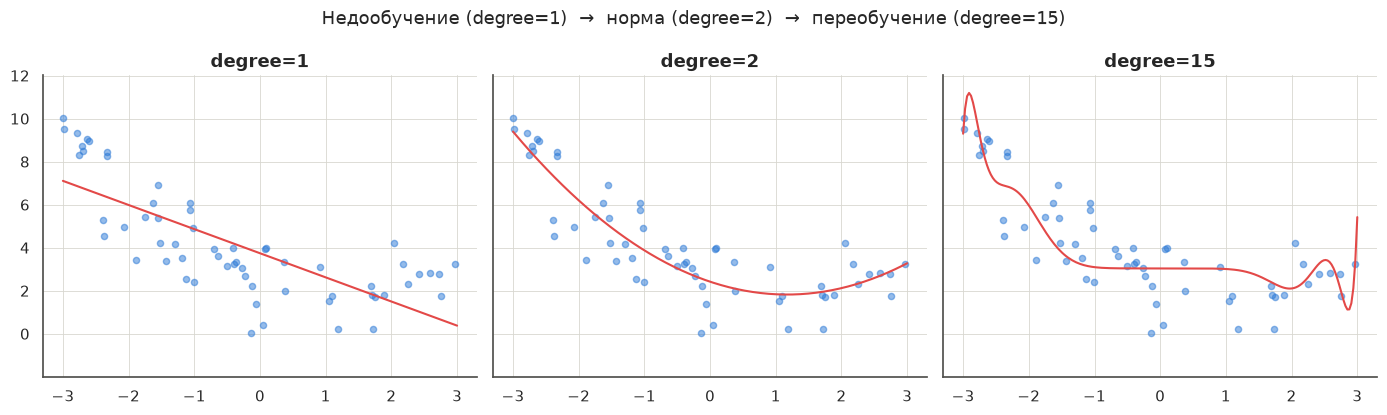

In [9]:
x_nl = np.sort(rng.uniform(-3, 3, 60))
y_nl = 0.5 * x_nl**2 - x_nl + 2 + rng.normal(0, 1.2, 60)

degrees = [1, 2, 15]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
x_grid = np.linspace(-3, 3, 200).reshape(-1, 1)

for ax, degree in zip(axes, degrees):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x_nl.reshape(-1, 1))
    model = LinearRegression().fit(X_poly, y_nl)
    y_grid = model.predict(poly.transform(x_grid))

    ax.scatter(x_nl, y_nl, alpha=0.5, color=CATEGORICAL_PALETTE[0], s=20)
    ax.plot(x_grid, y_grid, color=CATEGORICAL_PALETTE[3])
    ax.set_title(f"degree={degree}")
    ax.set_ylim(y_nl.min() - 2, y_nl.max() + 2)
fig.suptitle("Недообучение (degree=1)  →  норма (degree=2)  →  переобучение (degree=15)")
fig.tight_layout()
plt.show()

- **degree=1** (обычная прямая) — **недообучение**: модель слишком проста,
  чтобы уловить параболическую форму данных, ошибка большая и на train, и на
  новых точках.
- **degree=2** — соответствует истинной форме зависимости, хорошее
  обобщение.
- **degree=15** — **переобучение**: модель гоняется за каждой шумовой
  точкой обучающей выборки, между точками её выдаёт в дикие колебания —
  на новых данных такая модель предскажет плохо, несмотря на почти нулевую
  ошибку на train.

## 9. Bias-variance tradeoff

Формально ошибку модели на новых данных можно разложить на три слагаемых:

$$\mathbb{E}[(y-\hat{y})^2] = \underbrace{\text{Bias}^2}_{\text{недообучение}} + \underbrace{\text{Variance}}_{\text{переобучение}} + \underbrace{\sigma^2}_{\text{неустранимый шум}}$$

- **Bias** (смещение) — насколько в среднем модель ошибается из-за того,
  что она *слишком простая* для истинной зависимости.
- **Variance** (дисперсия) — насколько сильно предсказания модели меняются
  при обучении на разных выборках из той же генеральной совокупности —
  чувствительность к конкретному шуму в train.

Простая модель (degree=1) — высокий bias, низкая variance. Сложная модель
(degree=15) — низкий bias, высокая variance. Посмотрим на train/test ошибку
как функцию сложности модели:

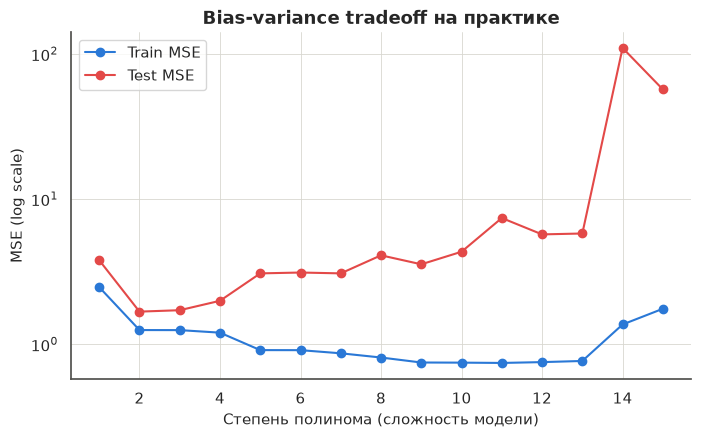

In [10]:
from sklearn.model_selection import train_test_split

x_tr, x_te, y_tr, y_te = train_test_split(x_nl, y_nl, test_size=0.3, random_state=0)
degree_range = range(1, 16)
train_errors, test_errors = [], []

for degree in degree_range:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr_poly = poly.fit_transform(x_tr.reshape(-1, 1))
    X_te_poly = poly.transform(x_te.reshape(-1, 1))
    model = LinearRegression().fit(X_tr_poly, y_tr)
    train_errors.append(mean_squared_error(y_tr, model.predict(X_tr_poly)))
    test_errors.append(mean_squared_error(y_te, model.predict(X_te_poly)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(degree_range), train_errors, "-o", color=CATEGORICAL_PALETTE[0], label="Train MSE")
ax.plot(list(degree_range), test_errors, "-o", color=CATEGORICAL_PALETTE[3], label="Test MSE")
ax.set_yscale("log")
ax.set_xlabel("Степень полинома (сложность модели)"); ax.set_ylabel("MSE (log scale)")
ax.legend(); ax.set_title("Bias-variance tradeoff на практике")
plt.show()

Train-ошибка монотонно падает с ростом сложности (модель всё точнее
подгоняется под конкретные точки train). Test-ошибка сначала тоже падает
(модель ловит настоящую зависимость), но затем разворачивается и растёт —
модель начинает подстраиваться под шум, специфичный для train-выборки, и
теряет обобщающую способность. Момент разворота — примерно оптимальная
сложность модели для этой задачи.

## 10. Регуляризация: Ridge, Lasso, ElasticNet

Регуляризация — способ бороться с переобучением и мультиколлинеарностью,
не уменьшая явно число признаков, а **штрафуя** модель за слишком большие
по модулю веса (в духе того самого bias-variance tradeoff: чуть увеличиваем
bias, заметно снижаем variance).

$$\text{Ridge (L2):}\quad \min_w \; MSE(w) + \lambda \sum_j w_j^2 \qquad\qquad
\text{Lasso (L1):}\quad \min_w \; MSE(w) + \lambda \sum_j |w_j|$$

$$\text{ElasticNet:}\quad \min_w \; MSE(w) + \lambda_1 \sum_j |w_j| + \lambda_2 \sum_j w_j^2$$

Геометрически: L2 "сжимает" все веса к нулю плавно и одновременно (штраф —
гладкая сфера), а L1 — за счёт "острых углов" ромбовидной области допустимых
$w$ — обнуляет часть весов **полностью**, производя отбор признаков.
Посмотрим на это на модели с намеренно избыточным числом коррелированных
признаков:

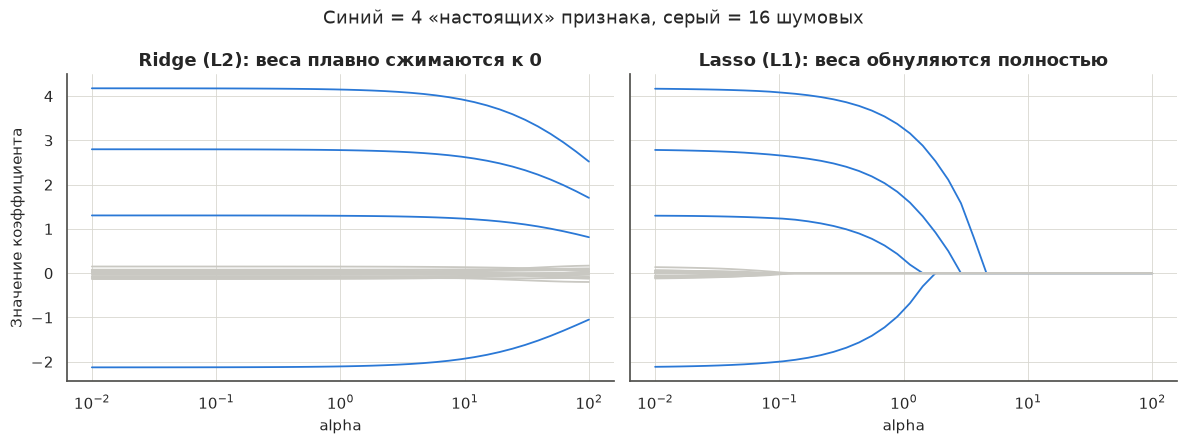

In [11]:
n_feat = 20
X_reg = rng.normal(0, 1, (150, n_feat))
true_coef = np.zeros(n_feat)
true_coef[:4] = [3, -2, 1.5, 4]  # только 4 признака из 20 реально влияют на y
y_reg = X_reg @ true_coef + rng.normal(0, 1, 150)
X_reg_scaled = StandardScaler().fit_transform(X_reg)

alphas = np.logspace(-2, 2, 40)
ridge_paths = np.array([Ridge(alpha=a).fit(X_reg_scaled, y_reg).coef_ for a in alphas])
lasso_paths = np.array([Lasso(alpha=a).fit(X_reg_scaled, y_reg).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for j in range(n_feat):
    color = CATEGORICAL_PALETTE[0] if j < 4 else "#c9c8c2"
    axes[0].plot(alphas, ridge_paths[:, j], color=color, linewidth=1.3)
    axes[1].plot(alphas, lasso_paths[:, j], color=color, linewidth=1.3)
for ax, title in zip(axes, ["Ridge (L2): веса плавно сжимаются к 0", "Lasso (L1): веса обнуляются полностью"]):
    ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_title(title)
axes[0].set_ylabel("Значение коэффициента")
fig.suptitle("Синий = 4 «настоящих» признака, серый = 16 шумовых")
fig.tight_layout()
plt.show()

При росте `alpha` у Ridge все 16 шумовых коэффициентов дружно уменьшаются,
но не становятся равными нулю в точности. У Lasso при том же росте `alpha`
шумовые коэффициенты один за другим "обнуляются" — Lasso выполняет неявный
отбор признаков. ElasticNet — взвешенная комбинация обоих штрафов, полезна,
когда среди коррелированных признаков хочется и отбора (как в Lasso), и
устойчивости к мультиколлинеарности (как в Ridge, который не "разрывает"
случайно один из пары сильно коррелированных признаков в пользу другого).

**Когда что использовать:**

| Ситуация | Метод |
|---|---|
| Признаков немного, все потенциально полезны, есть мультиколлинеарность | Ridge |
| Много признаков, подозрение, что часть — шум, нужен отбор | Lasso |
| Много коррелированных признаков + нужен отбор | ElasticNet |
| Данные чистые, мало признаков, переобучение не грозит | Обычная LinearRegression |

## 11. Диагностика обученной модели

Обучить модель — не значит закончить работу: нужно проверить, насколько
оправданы предположения, на которых строится линейная регрессия (условия
Гаусса-Маркова: линейность, гомоскедастичность, отсутствие сильной
мультиколлинеарности — подробный список см. `questions.md`).

### Residual plot — проверка линейности и гомоскедастичности

По оси X — предсказания, по оси Y — остатки ($y - \hat{y}$). Если модель
адекватна, остатки должны быть хаотичным облаком вокруг нуля, без формы.

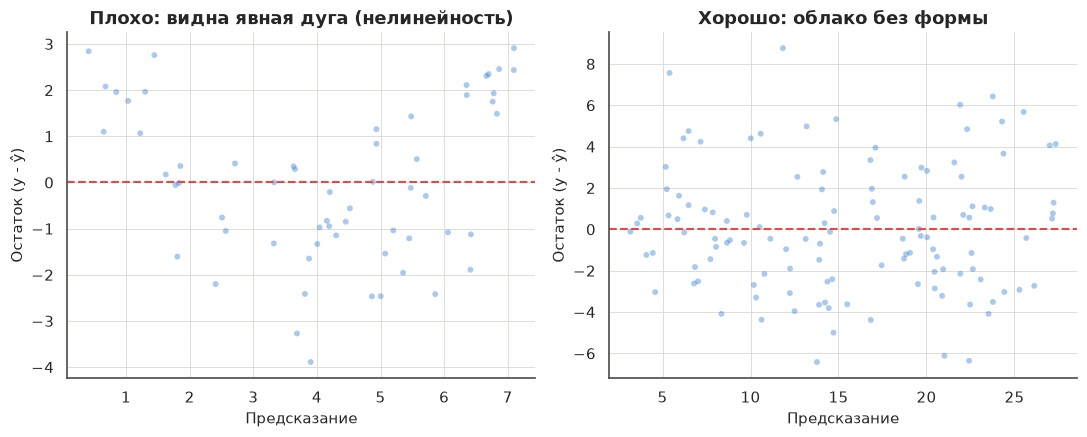

In [12]:
# специально обучим линейную модель на НЕЛИНЕЙНЫХ данных (degree=1 на параболе) - см. раздел 8
poly1 = PolynomialFeatures(degree=1, include_bias=False)
model_bad = LinearRegression().fit(poly1.fit_transform(x_nl.reshape(-1, 1)), y_nl)
y_pred_bad = model_bad.predict(poly1.transform(x_nl.reshape(-1, 1)))

model_good = LinearRegression().fit(x.reshape(-1, 1), y)  # x, y - линейные данные из раздела 1
y_pred_good = model_good.predict(x.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_residuals(y_nl, y_pred_bad, title="Плохо: видна явная дуга (нелинейность)", ax=axes[0])
plot_residuals(y, y_pred_good, title="Хорошо: облако без формы", ax=axes[1])
fig.tight_layout()
plt.show()

Слева чёткая парабола в остатках — прямой сигнал, что зависимость на самом
деле нелинейна и модели не хватает полиномиальных признаков. Справа —
случайное облако вокруг нуля, форма отсутствует: линейная модель адекватна
данным.

### Тест Бройша-Пагана — гетероскедастичность

"На глаз" можно спутать однородный и неоднородный разброс остатков.
Формальный тест: p-value < 0.05 означает, что дисперсия остатков значимо
зависит от предсказания (гетероскедастичность).

In [13]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_with_const = sm.add_constant(x.reshape(-1, 1))
residuals_good = y - y_pred_good
lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals_good, X_with_const)
print(f"Breusch-Pagan p-value: {lm_pvalue:.4f}",
      "-> гомоскедастичны" if lm_pvalue >= 0.05 else "-> гетероскедастичность!")

Breusch-Pagan p-value: 0.3971 -> гомоскедастичны


### VIF — мультиколлинеарность

Variance Inflation Factor для признака $j$ — во сколько раз дисперсия его
коэффициента увеличена из-за корреляции с остальными признаками:
$VIF_j = \dfrac{1}{1 - R_j^2}$, где $R_j^2$ — коэффициент детерминации
регрессии признака $j$ на все остальные признаки. $VIF > 5$ — умеренная
коллинеарность, $VIF > 10$ — критическая. Полный разбор на реальных данных
(с наглядным `inf` для идеально коллинеарных признаков) — в
`notebooks/02_house_prices_eda.ipynb`, раздел 5.

## 12. Метрики качества

$$MAE = \frac{1}{n}\sum|y_i - \hat{y}_i\vert
\qquad
RMSE = \sqrt{\frac{1}{n}\sum (y_i-\hat{y}_i)^2}
\qquad
R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

- **MAE** — средняя ошибка в исходных единицах, устойчива к выбросам.
- **RMSE** — тоже в исходных единицах, но сильнее штрафует за крупные
  промахи (наследует чувствительность MSE к выбросам).
- **$R^2$** — доля дисперсии таргета, объяснённая моделью: 1.0 — идеально,
  0.0 — не лучше, чем константа $\bar{y}$; может уходить в минус, если
  модель хуже константы.

**Ловушка:** обычный $R^2$ никогда не уменьшается при добавлении новых
признаков, даже абсолютно бесполезных — модель всегда найдёт микроскопическую
случайную корреляцию. **Adjusted $R^2$** штрафует за число признаков $k$:

$$R^2_{adj} = 1 - (1-R^2)\frac{n-1}{n-k-1}$$

и может уменьшаться, если новый признак не окупает штраф за усложнение —
поэтому именно adjusted $R^2$ корректен для сравнения моделей с разным
числом признаков.

In [14]:
def adjusted_r2(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

print(f"MAE:  {mean_absolute_error(y, y_pred_good):.3f}")
print(f"RMSE: {root_mean_squared_error(y, y_pred_good):.3f}")
print(f"R2:   {r2_score(y, y_pred_good):.3f}")
print(f"Adjusted R2 (k=1): {adjusted_r2(y, y_pred_good, n_features=1):.3f}")

MAE:  2.408
RMSE: 3.023
R2:   0.835
Adjusted R2 (k=1): 0.834


## 13. Геометрическая интерпретация: OLS как проекция

Столбцы матрицы $X$ натягивают линейное подпространство в $\mathbb{R}^n$.
Вектор предсказаний $\hat{y} = Xw^*$ обязан лежать в этом подпространстве
(это любая линейная комбинация столбцов $X$). Минимизация $\|y - Xw\|^2$ —
это в точности поиск **ближайшей** к $y$ точки в этом подпространстве, а
ближайшая точка до плоскости — всегда её ортогональная проекция. Отсюда:

$$\hat{y} = Xw^* \;\; \text{— ортогональная проекция } y \text{ на пространство столбцов } X,
\qquad X^Te = 0 \;\; (e = y - \hat{y})$$

То, что вектор остатков $e$ ортогонален каждому столбцу $X$ — ровно то же
условие $X^T(y-Xw)=0$, из которого мы вывели нормальное уравнение в разделе
3, просто увиденное геометрически.

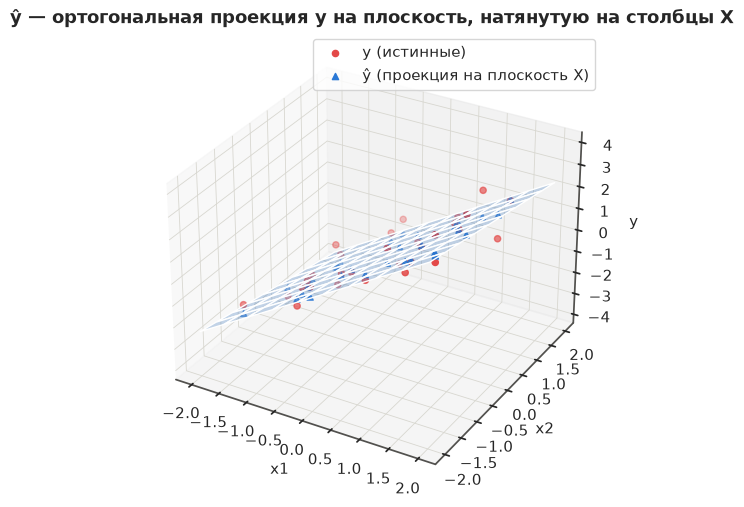

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 2 признака -> подпространство X это плоскость в R^3, y - точка вне плоскости
n_pts = 30
x1_geo = rng.uniform(-2, 2, n_pts)
x2_geo = rng.uniform(-2, 2, n_pts)
y_geo = 1.5 * x1_geo - 0.5 * x2_geo + rng.normal(0, 0.6, n_pts)

model_geo = LinearRegression(fit_intercept=False).fit(np.column_stack([x1_geo, x2_geo]), y_geo)
y_hat_geo = model_geo.predict(np.column_stack([x1_geo, x2_geo]))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
xx, yy = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-2, 2, 10))
zz = model_geo.coef_[0] * xx + model_geo.coef_[1] * yy
ax.plot_surface(xx, yy, zz, alpha=0.25, color=CATEGORICAL_PALETTE[0])
ax.scatter(x1_geo, x2_geo, y_geo, color=CATEGORICAL_PALETTE[3], label="y (истинные)")
ax.scatter(x1_geo, x2_geo, y_hat_geo, color=CATEGORICAL_PALETTE[0], marker="^", label="ŷ (проекция на плоскость X)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
ax.legend()
ax.set_title("ŷ — ортогональная проекция y на плоскость, натянутую на столбцы X")
plt.show()

## 14. Резюме

- Линейная регрессия минимизирует $MSE$; при выпуклой квадратичной функции
  потерь есть ровно один глобальный минимум — либо аналитически (нормальное
  уравнение), либо итеративно (градиентный спуск).
- Аналитика — точна и быстра при небольшом числе признаков и невырожденной
  $X^TX$; градиентный спуск — единственный практичный вариант при больших
  $n$/$k$, но требует стандартизации признаков и подбора `learning rate`.
- Полиномиальные признаки превращают линейную регрессию в гибкий
  нелинейный инструмент — ценой риска переобучения; баланс сложности —
  это и есть bias-variance tradeoff.
- Регуляризация (Ridge/Lasso/ElasticNet) — стандартный способ снизить
  variance и побороть мультиколлинеарность, не удаляя признаки вручную.
- Обученную модель обязательно нужно диагностировать: residual plot
  (линейность), тест Бройша-Пагана (гомоскедастичность), VIF
  (мультиколлинеарность) — а не полагаться на один $R^2$.

**Дальше:** `tutorials/logisticregression.ipynb` — тот же путь (постановка
задачи → функция потерь → обучение → метрики) для задачи классификации.